In [1]:
import os 
print(os.getcwd())
os.chdir("../code/SPID_code")

print(os.getcwd())

c:\GitHub\GGSpeciale\quadcopter-suite
c:\GitHub\GGSpeciale\code\SPID_code


In [2]:
import socket

print("Host:", socket.gethostname())
print("SLURM job:", os.environ.get("SLURM_JOB_ID"))

Host: SofiesPC
SLURM job: None


# Load packages

In [3]:
from gmDAGGER import train_spid
from PySRWrapper import PySRPolicy
from stable_baselines3 import PPO
import matplotlib.pyplot as plt

import warnings

from stable_baselines3 import PPO
from gym_pybullet_drones.envs.HoverAviary import HoverAviary
from gym_pybullet_drones.utils.enums import ObservationType, ActionType
import gymnasium as gym
import numpy as np

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
C:\GitHub\gym-pybullet-drones\gym_pybullet_drones\envs\BaseAviary.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
I0000 00:00:1776246032.908756   19804 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-of

# Distill teacher PPO model

In [4]:

warnings.filterwarnings(
    "ignore",
    message="You are trying to run PPO on the GPU"
)

warnings.filterwarnings(
    "ignore",
    message="Note: it looks like you are running in Jupyter"
)

# example

# rewards, best_policy, wrapper, run_dir = train_spid(r"/home/ashc/GGSpeciale/ashc_repo/GGSpeciale/code/baseline_code/baseline_models/cartpole/PPO_cartpole.zip", PPO, "", "CartPole-v1", n_iter=1, total_timesteps=3, verbose=2)

teacher_model_path = r"C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip"
teacher_model = PPO
environment = HoverAviary # ContinuousCartPoleEnv #"Swimmer-v5" # or use string like CartPole-v1

DEFAULT_OBS = ObservationType('kin') # 'kin' or 'rgb'
DEFAULT_ACT = ActionType('one_d_rpm') # 'rpm' or 'pid' or 'vel' or 'one_d_rpm' or 'one_d_pid'

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

environment = lambda: HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=False
    )
)

rewards, best_policy, wrapper, run_dir = train_spid(teacher_path = teacher_model_path, 
                                                    teacher_model = teacher_model, 
                                                    save_folder_path="C:/GitHub/GGSpeciale/quadcopter-suite/distil-results_1000x12_no_Q", 
                                                    save_results=True, 
                                                    environment=environment, 
                                                    n_iter=20, 
                                                    total_timesteps=20*1000, 
                                                    n_eval_episodes=10,
                                                    verbose=2)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\torch\cuda\__init__.py:184: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\bld\libtorch_1770197068560\work\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip
finished collecting trajectories
computing advantages
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
training
Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_

c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 0: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip


...

Evaluating trained model
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Iteration 19: student reward = 333.8626 +/- 0.0000
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
Loaded local teacher from: C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
SPID iteration complete. Dataset size: 3
Best policy iteration: 4
Best student reward during search: 471.7657
Teacher eval: 474.1320 +/- 0.0000
Student eval: 471.7645 +/- 0.0013
Saved results to: C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12_no_Q


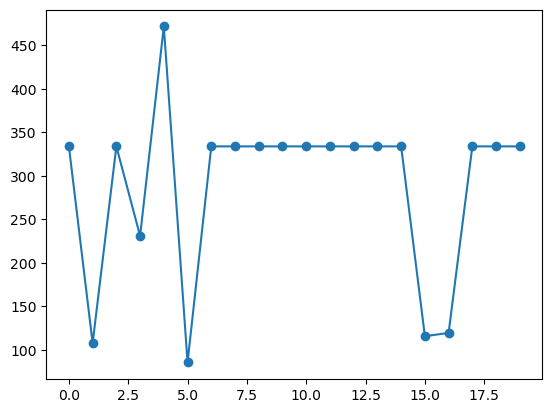

In [5]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)

## Visualize distilled model 

In [40]:
import time
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")


class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)


env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
    )
)

obs, info = env.reset()

episode_reward = 0.0

for t in range(2000):
    # PySRPolicy.predict expects batch-style input
    action, _ = wrapper.predict(obs, deterministic=True)

    # For a single non-vec env, unwrap batch dimension
    action = np.asarray(action, dtype=np.float32)
    if action.ndim == 2 and action.shape[0] == 1:
        action = action[0]

    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    time.sleep(1 / 60)  # adjust for display speed

    if terminated or truncated:
        print("Episode reward:", episode_reward)
        obs, info = env.reset()
        episode_reward = 0.0

env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


error: Only one local in-process GUI/GUI_SERVER connection allowed. Use DIRECT connection mode or start a separate GUI physics server (ExampleBrowser, App_SharedMemoryPhysics_GUI, App_SharedMemoryPhysics_VR) and connect over SHARED_MEMORY, UDP or TCP instead.

In [3]:
import time
from PySRWrapper import PySRPolicy
DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")


class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)


env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
        record=True
    )
)

obs, info = env.reset()

episode_reward = 0.0

wrapper = PySRPolicy.load(path=r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12\best_student_policy.joblib")

for t in range(2000):
    # PySRPolicy.predict expects batch-style input
    action, _ = wrapper.predict(obs, deterministic=True)

    # For a single non-vec env, unwrap batch dimension
    action = np.asarray(action, dtype=np.float32)
    if action.ndim == 2 and action.shape[0] == 1:
        action = action[0]

    obs, reward, terminated, truncated, info = env.step(action)
    episode_reward += reward

    time.sleep(1 / 60)  # adjust for display speed

    if terminated or truncated:
        print("Episode reward:", episode_reward)
        obs, info = env.reset()
        episode_reward = 0.0
        break

env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.642787516117096, -0.4393851161003113, 0.6275069713592529, 0.0, 0.766044557094574, 0.36868777871131897, -0.5265407562255859, 0.0, -0.0, 0.8191521167755127, 0.5735764503479004, 0.0, 2.384185791015625e-07, 2.384185791015625e-07, -5.000000476837158, 1.0)
projectionMatrix (0.7499999403953552, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0000200271606445, -1.0, 0.0, 0.0, -0.02000020071864128, 0.0)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Policy loaded
Episode reward: 475.10372561573973


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 22.1.0
  configuration: --prefix=/d/bld/ffmpeg_1773007679189/_h_env/Library --cc=clang.exe --cxx=clang++.exe --nm=llvm-nm --ar=llvm-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --ld=lld-link --target-os=win64 --enable-cross-compile --toolchain=msvc --host-cc=clang.exe --extra-libs=ucrt.lib --extra-libs=vcruntime.lib --extra-libs=oldnames.lib --strip=llvm-strip --disable-stripping --host-extralibs= --disable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-librsvg --enable-libjxl --enable-libwebp --enable-ffplay --enable-vulkan --enable-libshaderc --pkg-c

starting thread 0
started testThreads thread 0 with threadHandle 0000000000002CFC
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 NVIDIA 555.99
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce GTX 1650/PCIe/SSE2
b3Printf: Selected demo: Physics Server
starting thread 0
started MotionThreads thread 0 with threadHandle 0000000000002FA8
MotionThreadFunc thread started
numActiveThreads = 0
stopping threads
Thread with taskId 0 with handle 0000000000002FA8 exiting
Thread TERMINATED
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 with handle 0000000000002CFC exiting
Thread TERMINATED


# Recording episodes

In [6]:
import time
import gymnasium as gym
import numpy as np
import pybullet as p

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

env = HoverActionShapeWrapper(
    HoverAviary(
        obs=DEFAULT_OBS,
        act=DEFAULT_ACT,
        gui=True,
        record=False,   # disable built-in recorder
    )
)

wrapper = PySRPolicy.load(
    path=r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12\best_student_policy.joblib"
)

obs, info = env.reset()
episode_reward = 0.0

video_id = p.startStateLogging(p.STATE_LOGGING_VIDEO_MP4, "hover_episode.mp4")

try:
    for t in range(2000):
        action, _ = wrapper.predict(obs, deterministic=True)

        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 2 and action.shape[0] == 1:
            action = action[0]

        obs, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        time.sleep(1 / 20)

        if terminated or truncated:
            print("Episode reward:", episode_reward)
            break
finally:
    p.stopStateLogging(video_id)
    env.close()

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (-0.8660253882408142, -0.2499999701976776, 0.4330126941204071, 0.0, 0.0, 0.8660253286361694, 0.4999999701976776, 0.0, -0.4999999701976776, 0.4330126643180847, -0.75, 0.0, -0.0, 5.960464477539063e-08, -2.999999761581421, 1.0)
projectionMatrix (1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, -1.0000200271606445, -1.0, 0.0, 0.0, -0.02000020071864128, 0.0)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


Policy loaded


ffmpeg version 8.0.1 Copyright (c) 2000-2025 the FFmpeg developers
  built with clang version 22.1.0
  configuration: --prefix=/d/bld/ffmpeg_1773007679189/_h_env/Library --cc=clang.exe --cxx=clang++.exe --nm=llvm-nm --ar=llvm-ar --disable-doc --enable-openssl --enable-demuxer=dash --enable-hardcoded-tables --enable-libfreetype --enable-libharfbuzz --enable-libfontconfig --enable-libopenh264 --enable-libdav1d --ld=lld-link --target-os=win64 --enable-cross-compile --toolchain=msvc --host-cc=clang.exe --extra-libs=ucrt.lib --extra-libs=vcruntime.lib --extra-libs=oldnames.lib --strip=llvm-strip --disable-stripping --host-extralibs= --disable-libopenvino --enable-gpl --enable-libx264 --enable-libx265 --enable-libmp3lame --enable-libaom --enable-libsvtav1 --enable-libxml2 --enable-pic --enable-shared --disable-static --enable-version3 --enable-zlib --enable-libvorbis --enable-libopus --enable-librsvg --enable-libjxl --enable-libwebp --enable-ffplay --enable-vulkan --enable-libshaderc --pkg-c

Episode reward: 475.10372561573973
starting thread 0
started testThreads thread 0 with threadHandle 0000000000001EF0
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 NVIDIA 555.99
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce GTX 1650/PCIe/SSE2
b3Printf: Selected demo: Physics Server
starting thread 0
started MotionThreads thread 0 with threadHandle 0000000000002EF0
MotionThreadFunc thread started
numActiveThreads = 0
stopping threads
Thread with taskId 0 with handle 0000000000002EF0 exiting
Thread TERMINATED
finished
numActiveThreads = 0
btShutDownExampleBrowser stopping threads
Thread with taskId 0 with handle 0000000000001EF0 exiting
Thread TERMINATED


In [15]:
import time
import gymnasium as gym
import numpy as np
import pybullet as p

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

def record_episode(policy, output_file, seed=0, max_steps=2000, sleep_s=1/30):
    env = HoverActionShapeWrapper(
        HoverAviary(
            obs=DEFAULT_OBS,
            act=DEFAULT_ACT,
            gui=True,
            record=False,
        )
    )

    obs, info = env.reset(seed=seed)
    episode_reward = 0.0

    # p.configureDebugVisualizer(p.COV_ENABLE_GUI, 0)
    # video_id = p.startStateLogging(p.STATE_LOGGING_VIDEO_MP4, output_file)

    actions = []
    rewards = []

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=True)
            # print("==== obs ====")
            # print(obs.shape)
            # print(obs)
            # print("==== action ====")
            # print(action)
            # print("========")

            action = np.asarray(action, dtype=np.float32)
            if action.ndim == 2 and action.shape[0] == 1:
                action = action[0]

            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward

            time.sleep(sleep_s)

            actions.append(action)
            rewards.append(reward)

            if terminated or truncated:
                break

    finally:
        #plt.plot(actions, range(max_steps))
        # p.stopStateLogging(video_id)
        env.close()
        

    print(f"{output_file}: reward = {episode_reward}")
    return  rewards, np.array(actions).flatten()

teacher = PPO.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\results\save-04.10.2026_15.39.13\best_model.zip")
student = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12\best_student_policy.joblib")

teacher_rewards, teacher_actions = record_episode(teacher, "teacher.mp4", seed=42)
student_rewards, student_actions = record_episode(student, "student_no_weights.mp4", seed=42)

Policy loaded
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
projectionMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


teacher.mp4: reward = 474.13203048587195
[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000
viewMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
projectionMatrix (0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0)
student_no_weights.mp4: reward = 475.10372561573973
starting thread 0
started testThreads thread 0 with threadHandle 0000000000002B10
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
Version = 4.6.0 NVIDIA 555.99
Vendor = NVIDIA Corporation
Renderer = NVIDIA GeForce GTX 1650/PCIe/SSE2
b3Printf: S

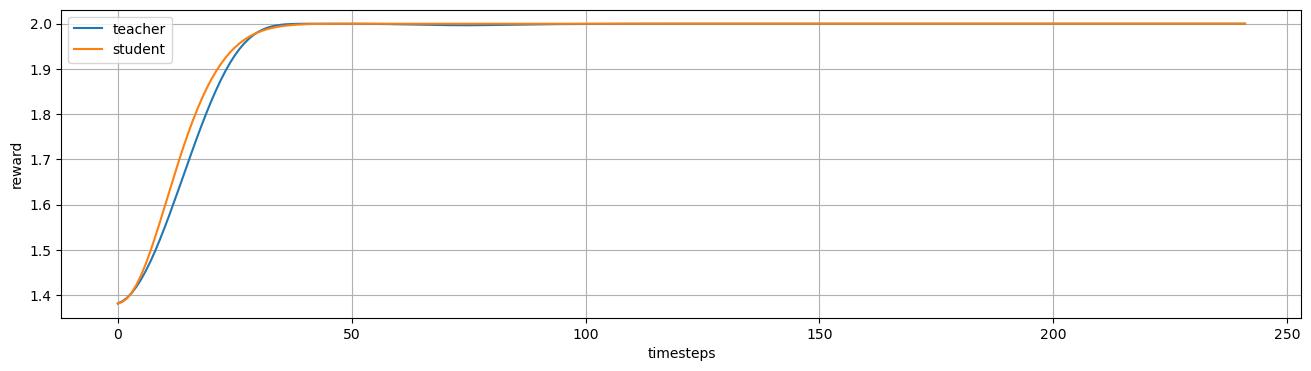

In [24]:
plt.figure(figsize=(16, 4))
plt.plot(teacher_rewards, label = "teacher")
plt.plot(student_rewards, label = "student")
plt.grid()
plt.xlabel("timesteps")
plt.ylabel("reward")
plt.legend()

Text(0.5, 0, 'timesteps')

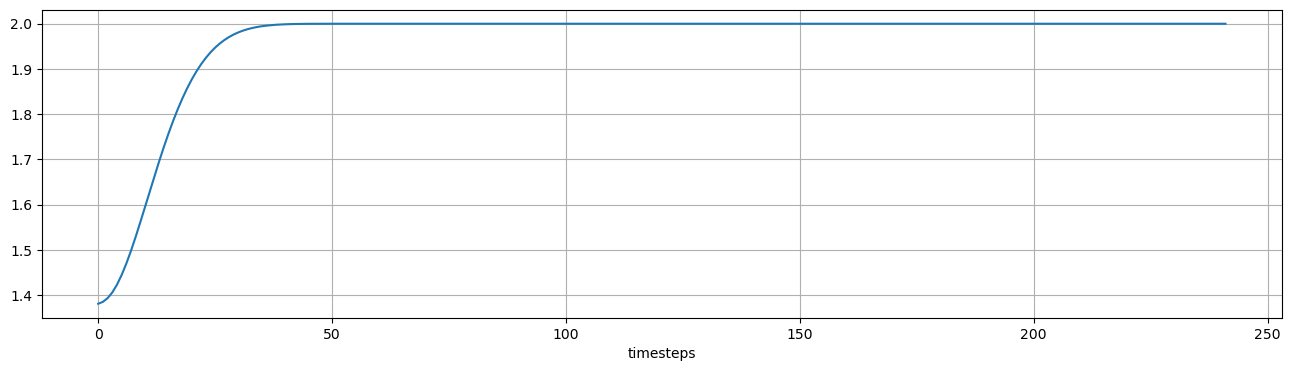

In [ ]:
plt.figure(figsize=(16, 4))

plt.grid()
plt.xlabel("timesteps")

Text(0.5, 0, 'timesteps')

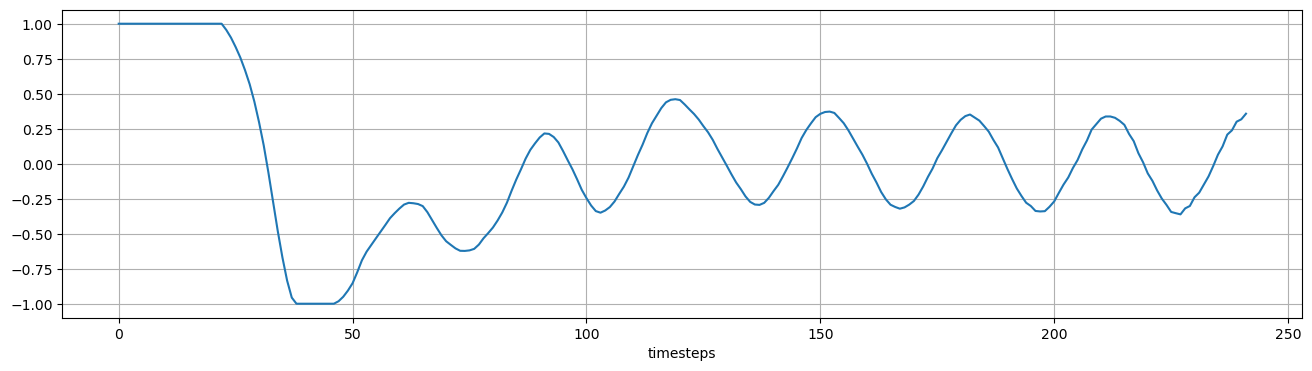

In [22]:
plt.figure(figsize=(16, 4))
plt.plot(teacher_actions)
plt.grid()
plt.xlabel("timesteps")

Text(0.5, 0, 'timesteps')

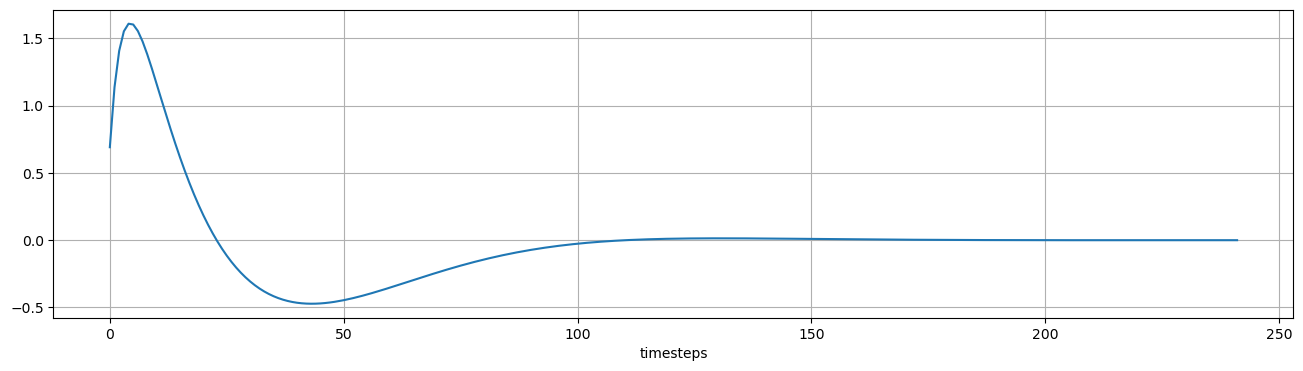

In [25]:
plt.figure(figsize=(16, 4))
plt.plot(student_actions)
plt.grid()
plt.xlabel("timesteps")

In [15]:
import gymnasium as gym
import numpy as np
import pybullet as p
import imageio.v2 as imageio

DEFAULT_OBS = ObservationType("kin")
DEFAULT_ACT = ActionType("one_d_rpm")

class HoverActionShapeWrapper(gym.Wrapper):
    def step(self, action):
        action = np.asarray(action, dtype=np.float32)
        if action.ndim == 1:
            action = action.reshape(1, -1)
        return self.env.step(action)

def record_clean_episode(policy, output_file="hover_clean.mp4", seed=42, max_steps=20,
                         width=1280, height=720, fps=30):
    env = HoverActionShapeWrapper(
        HoverAviary(
            obs=DEFAULT_OBS,
            act=DEFAULT_ACT,
            gui=False,      # no visible GUI window
            record=False,   # do not use built-in recorder
        )
    )

    obs, info = env.reset(seed=seed)
    writer = imageio.get_writer(output_file, fps=fps, codec="libx264")

    try:
        for _ in range(max_steps):
            action, _ = policy.predict(obs, deterministic=True)

            action = np.asarray(action, dtype=np.float32)
            if action.ndim == 2 and action.shape[0] == 1:
                action = action[0]

            obs, reward, terminated, truncated, info = env.step(action)

            # Adjust these camera parameters to taste
            view_matrix = p.computeViewMatrixFromYawPitchRoll(
                cameraTargetPosition=[0, 0, 0.5],
                distance=1.4,
                yaw=45,
                pitch=-30,
                roll=0,
                upAxisIndex=2,
            )

            proj_matrix = p.computeProjectionMatrixFOV(
                fov=60,
                aspect=width / height,
                nearVal=0.1,
                farVal=100.0,
            )

            img = p.getCameraImage(
                width=width,
                height=height,
                viewMatrix=view_matrix,
                projectionMatrix=proj_matrix,
                renderer=p.ER_BULLET_HARDWARE_OPENGL,  # try this first
            )

            rgba = np.reshape(img[2], (height, width, 4))
            rgb = rgba[:, :, :3]
            writer.append_data(rgb)

            if terminated or truncated:
                break
    finally:
        writer.close()
        env.close()

record_clean_episode(student, output_file="hover_clean.mp4", seed=42, max_steps=2000,
                         width=1280, height=720, fps=30)

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 3.160000e-10, km 7.940000e-12,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warning.
Lossy conversion from int64 to uint8. Range [76, 255]. Convert image to uint8 prior to saving to suppress this warni

In [27]:
student = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12_no_Q\best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.get_best()["equation"]
    print("\nBest equation:")
    print(best_eq)


Policy loaded

=== Action dimension 0 ===

Best equation:
((x26 + (((x2 * -0.3379837) - ((x8 + x19) * 0.2871561)) * 0.42700613)) + 0.3779774) - 0.24113771


In [28]:
student = PySRPolicy.load(r"C:\GitHub\GGSpeciale\quadcopter-suite\distil-results_1000x12_no_Q\best_student_policy.joblib")
best_policy = student
for i, policy in enumerate(best_policy.policy_list):
    print(f"\n=== Action dimension {i} ===")

    sr = policy.sr
    
    best_eq = sr.latex()
    print(best_eq)

Policy loaded

=== Action dimension 0 ===
x_{26} + \left(x_{2} \left(-0.338\right) - \left(x_{19} + x_{8}\right) 0.287\right) 0.427 - 0.241 + 0.378


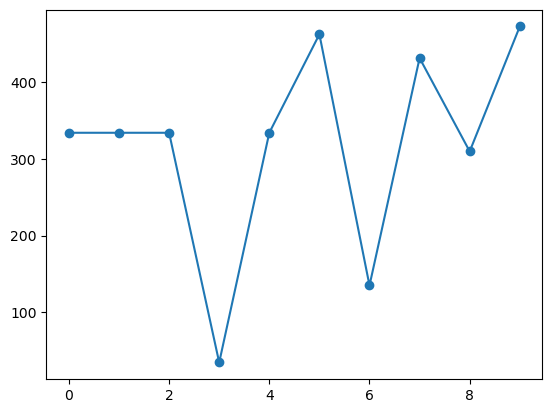

In [35]:
import matplotlib.pyplot as plt

plt.plot(range(len(rewards)), rewards)
plt.scatter(range(len(rewards)), rewards)